In [11]:
import numpy as np

phi_star=9.06e-4
M_star=-21.2
alpha=-1.78
M=np.linspace(-23,-17,500)
pc=3.0857*10**18

x=0.4*np.log(10)*phi_star*10**(-0.4*(M-M_star)*(alpha+1))
y=np.exp(-10**(-0.4*(M-M_star)))
phi=x*y


L=4*np.pi*(10*pc)**2*10**(-0.4*(M+48.6))

integrand=phi*L
rho_uv=np.trapz(integrand,M)
print("observed rho_uv(z=6):",rho_uv)

#intrinsic rho_uv
A=0.23
rho_uv1=rho_uv*10**(0.4*A)
print("Intrinsic rho_uv(z=6):",rho_uv1)

#rho_uv at 912 A
R=0.2
rho_uv_912=R*rho_uv1
print("Rho_uv at 912 A:",rho_uv_912)

#Ndot_gamma
h=6.26e-27
beta=1.5
ndot_gamma=rho_uv_912/(h*beta)
print("Ndot gamma:",ndot_gamma)

#Ndot ion
f_esc=0.1
ndot_ion=f_esc*ndot_gamma
print("IP production rate:",ndot_ion)

observed rho_uv(z=6): 2.6336262987446242e+26
Intrinsic rho_uv(z=6): 3.2550236645853837e+26
Rho_uv at 912 A: 6.510047329170768e+25
Ndot gamma: 6.932957752045546e+51
IP production rate: 6.932957752045546e+50


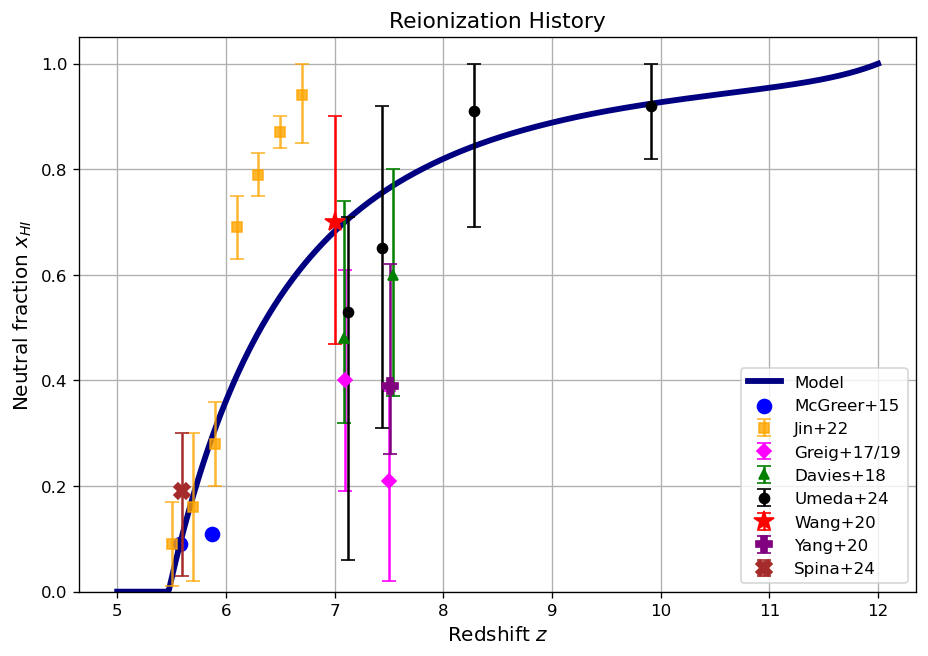

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# --- constants ---
H0 = 67.4 * 1000 / (3.085e22)      # Hubble constant (s^-1)
omega_m = 0.3                      # matter density
omega_l = 0.7                     # dark energy density
alpha_B = 2.6e-13              # recombination coefficient (cm^3/s)
C =3                     # clumping factor
nH0_cm3 = 2e-7                   # hydrogen number density (cm^-3)
              # your photon production rate (s^-1 Mpc^-3)
cm_per_Mpc = 3.08e24
dotn_ion = 6.93e50
ndot_ion=dotn_ion/(cm_per_Mpc)**3
z=np.linspace(12,5,500)


#Jin et al.2022
z_jin = [5.5,5.7,5.9,6.1,6.3,6.5,6.7]
x_jin = [0.09,0.16,0.28,0.69,0.79,0.87,0.94]
err_low_jin = [0.08,0.14,0.08,0.06,0.04,0.03,0.09]
err_high_jin = [0.08,0.14,0.08,0.06,0.04,0.03,0.06]
#McGreer et al.2015
z_mc = [5.58,5.87]
x_mc = [0.09,0.11]
#Greig et al.2017/2019
z_greig = [7.1,7.5]
x_greig = [0.4,0.21]
err_low_greig = [0.21,0.19]
err_high_greig = [0.21,0.17]
#Davies et al.2018
z_davies = [7.09,7.54]
x_davies = [0.48,0.6]
err_low_davies = [0.16,0.23]
err_high_davies = [0.26,0.20]
#Umeda et al.2024
z_umeda = [7.12,7.44,8.28,9.91]
x_umeda = [0.53,0.65,0.91,0.92]
err_low_umeda = [0.47,0.34,0.22,0.10]
err_high_umeda = [0.18,0.27,0.09,0.08]
#Wang et al.2020
z_wang = [7.0]
x_wang = [0.70]
err_low_wang = [0.23]
err_high_wang = [0.20]
#Yang et al.2020
z_yang = [7.51]
x_yang = [0.39]
err_low_yang = [0.13]
err_high_yang = [0.23]
#Spina et al.2024
z_spina = [5.6]
x_spina = [0.19]
err_low_spina = [0.16]
err_high_spina = [0.11]

# --- functions ---
def H(z):
    return H0 * np.sqrt(omega_m*(1+z)**3 + omega_l)



def dQ_dz(z, Q):
    source = ndot_ion / nH0_cm3
    recomb = alpha_B * C * nH0_cm3 * (1+z)**3
    return  -(1/((1+z)*H(z))) * (source - recomb * Q)

# --- solve from z=25 → 5 ---
z_span = (25,5)
z_eval = np.linspace(z_span[0], z_span[1], 500)
sol = solve_ivp(dQ_dz, z_span, [0], t_eval=z_eval)
sol1=np.clip(sol.y[0], 0, 1)
x_HI=1-sol1

plt.figure(figsize=(9,6), dpi=120)
plt.plot(z, x_HI, color='navy', linewidth=3.5,label='Model')
plt.errorbar(z_jin, x_jin,yerr=[err_low_jin,err_high_jin],fmt='s',color='orange',capsize=4,label='Jin+22',alpha =0.8)
plt.scatter(z_mc, x_mc,color='blue',marker='o',s=70,label='McGreer+15')
plt.errorbar(z_greig, x_greig,yerr=[err_low_greig,err_high_greig],fmt='D',color='magenta',capsize=4,label='Greig+17/19')
plt.errorbar(z_davies, x_davies,yerr=[err_low_davies,err_high_davies],fmt='^',color='green',capsize=4,label='Davies+18')
plt.errorbar(z_umeda, x_umeda,yerr=[err_low_umeda,err_high_umeda],fmt='o',color='black', capsize=4,label='Umeda+24')
plt.errorbar(z_wang, x_wang,yerr=[err_low_wang, err_high_wang],fmt='*',color='red',markersize=12,capsize=4,label='Wang+20')
plt.errorbar(z_yang, x_yang,yerr=[err_low_yang, err_high_yang],fmt='P',color='purple',markersize=10,capsize=4,label='Yang+20')
plt.errorbar(z_spina,x_spina,yerr=[err_low_spina, err_high_spina],fmt='X',color='brown',markersize=10,capsize=4,label='Spina+24')
plt.xlabel("Redshift $z$", fontsize=12)
plt.ylabel("Neutral fraction $x_{HI}$", fontsize=12)
plt.title("Reionization History", fontsize=13)
plt.ylim(0,1.05)
plt.legend(fontsize=10)
plt.grid(True)

plt.show()
